In [2]:
import os
import random
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split

# Reproducibility
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

In [3]:
# Dataset location (12 class folders inside)
DATA_DIR = Path(r'C:\Users\User\Downloads\archive (1)\garbage_classification')

# Split ratios (agreed with team: 70/15/15, stratified)
VAL_SIZE  = 0.15
TEST_SIZE = 0.15

print(f'data dir: {DATA_DIR}')
print(f'exists  : {DATA_DIR.exists()}')

data dir: C:\Users\User\Downloads\archive (1)\garbage_classification
exists  : True


##  Scan Dataset and Class imbalance

In [6]:
# Collect every image path and its integer class label
all_paths  = []
all_labels = []

class_list   = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
class_to_idx = {c: i for i, c in enumerate(class_list)}

for cls_name in class_list:
    cls_dir = DATA_DIR / cls_name
    for img_path in sorted(cls_dir.iterdir()):
        if img_path.suffix.lower() in {'.jpg', '.jpeg', '.png'}:
            all_paths.append(str(img_path))
            all_labels.append(class_to_idx[cls_name])

all_paths  = np.array(all_paths)
all_labels = np.array(all_labels)

print(f'classes ({len(class_list)}): {class_list}')
print(f'total images: {len(all_paths)}')
print(f'first sample: {all_paths[0]}')
print(f'              -> label={all_labels[0]} ({class_list[all_labels[0]]})')

classes (12): ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']
total images: 15515
first sample: C:\Users\User\Downloads\archive (1)\garbage_classification\battery\battery1.jpg
              -> label=0 (battery)


Class distribution:
          battery:   945
       biological:   985
      brown-glass:   607
        cardboard:   891
          clothes:  5325
      green-glass:   629
            metal:   769
            paper:  1050
          plastic:   865
            shoes:  1977
            trash:   697
      white-glass:   775

max class : clothes (5325 images)
min class : brown-glass (607 images)
imbalance ratio (max / min): 8.77x


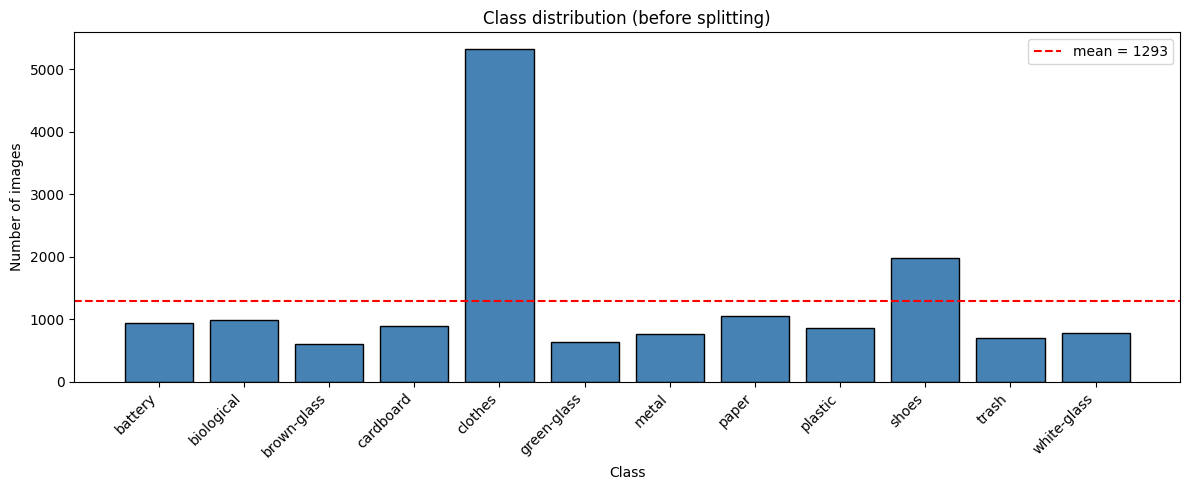

In [8]:
# Count images per class
counts        = Counter(all_labels)
class_counts  = np.array([counts[i] for i in range(len(class_list))])

print('Class distribution:')
for i, cls in enumerate(class_list):
    print(f'  {cls:>15s}: {class_counts[i]:>5d}')

max_idx = class_counts.argmax()
min_idx = class_counts.argmin()
print()
print(f'max class : {class_list[max_idx]} ({class_counts[max_idx]} images)')
print(f'min class : {class_list[min_idx]} ({class_counts[min_idx]} images)')
print(f'imbalance ratio (max / min): {class_counts[max_idx] / class_counts[min_idx]:.2f}x')

# Visualise class distribution
fig = plt.figure(figsize=[12, 5])
ax  = fig.add_subplot(1, 1, 1)
ax.bar(class_list, class_counts, color='steelblue', edgecolor='black')
ax.axhline(y=class_counts.mean(), color='red', linestyle='--',
           label=f'mean = {class_counts.mean():.0f}')
ax.set_ylabel('Number of images')
ax.set_xlabel('Class')
ax.set_title('Class distribution (before splitting)')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##  Stratification

train: 10859  (70.0%)
val  :  2328  (15.0%)
test :  2328  (15.0%)
total: 15515
          class    train    val   test   total
--------------------------------------------------
        battery      661    142    142     945
     biological      689    148    148     985
    brown-glass      425     91     91     607
      cardboard      623    134    134     891
        clothes     3727    799    799    5325
    green-glass      441     94     94     629
          metal      539    115    115     769
          paper      735    158    157    1050
        plastic      605    130    130     865
          shoes     1383    297    297    1977
          trash      488    104    105     697
    white-glass      543    116    116     775
--------------------------------------------------
          TOTAL    10859   2328   2328   15515


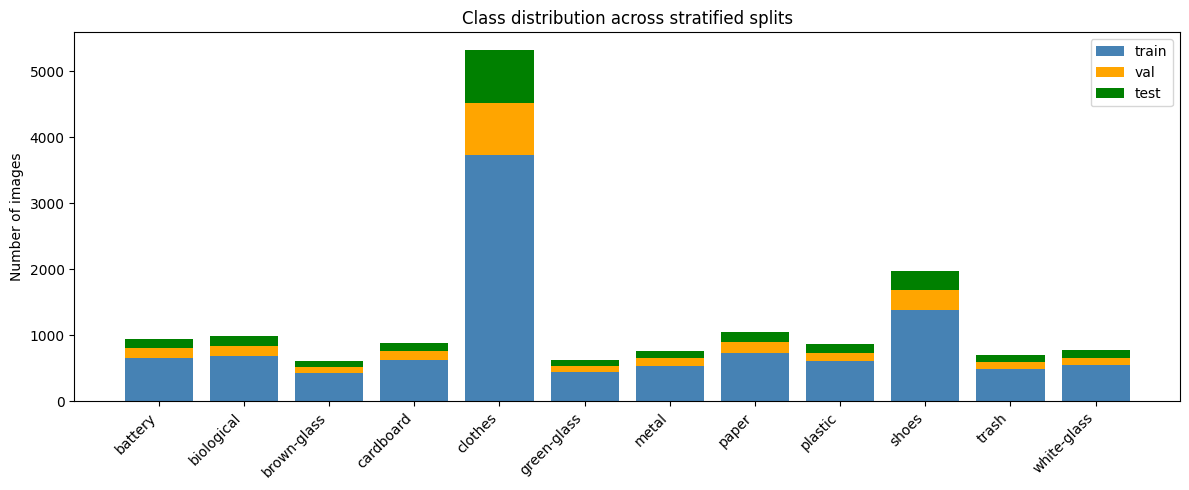

In [17]:
# Step 1: train+val vs test
trainval_paths, test_paths, trainval_labels, test_labels = train_test_split(
    all_paths,
    all_labels,
    test_size=TEST_SIZE,
    stratify=all_labels,
    random_state=RANDOM_STATE,
    shuffle=True,
)

# Step 2: train vs val
# val_ratio is relative to (train+val), not the whole dataset
val_ratio = VAL_SIZE / (1.0 - TEST_SIZE)

train_paths, val_paths, train_labels, val_labels = train_test_split(
    trainval_paths,
    trainval_labels,
    test_size=val_ratio,
    stratify=trainval_labels,
    random_state=RANDOM_STATE,
    shuffle=True,
)

print(f'train: {len(train_paths):>5d}  ({len(train_paths) / len(all_paths) * 100:.1f}%)')
print(f'val  : {len(val_paths):>5d}  ({len(val_paths) / len(all_paths) * 100:.1f}%)')
print(f'test : {len(test_paths):>5d}  ({len(test_paths) / len(all_paths) * 100:.1f}%)')
print(f'total: {len(all_paths):>5d}')

# Per-class counts across splits
print(f'{"class":>15s}  {"train":>7s}  {"val":>5s}  {"test":>5s}  {"total":>6s}')
print('-' * 50)

for i, cls in enumerate(class_list):
    n_train = (train_labels == i).sum()
    n_val   = (val_labels   == i).sum()
    n_test  = (test_labels  == i).sum()
    n_total = n_train + n_val + n_test
    print(f'{cls:>15s}  {n_train:>7d}  {n_val:>5d}  {n_test:>5d}  {n_total:>6d}')

print('-' * 50)
print(f'{"TOTAL":>15s}  {len(train_labels):>7d}  {len(val_labels):>5d}  '
      f'{len(test_labels):>5d}  {len(all_labels):>6d}')

# Visualise: stacked bar of per-class counts across splits
train_counts = np.array([(train_labels == i).sum() for i in range(len(class_list))])
val_counts   = np.array([(val_labels   == i).sum() for i in range(len(class_list))])
test_counts  = np.array([(test_labels  == i).sum() for i in range(len(class_list))])

fig = plt.figure(figsize=[12, 5])
ax  = fig.add_subplot(1, 1, 1)

x = np.arange(len(class_list))
ax.bar(x, train_counts,                       label='train', color='steelblue')
ax.bar(x, val_counts,  bottom=train_counts,   label='val',   color='orange')
ax.bar(x, test_counts, bottom=train_counts + val_counts, label='test', color='green')

ax.set_xticks(x)
ax.set_xticklabels(class_list, rotation=45, ha='right')
ax.set_ylabel('Number of images')
ax.set_title('Class distribution across stratified splits')
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
import csv

SPLITS_DIR = Path('data/splits')

def save_split_csv(paths, labels, csv_path):
    with open(csv_path, 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(['path', 'label'])
        for p, l in zip(paths, labels):
            
            rel_path = Path(p).relative_to(DATA_DIR).as_posix()
            writer.writerow([rel_path, int(l)])
    print(f'saved: {csv_path}  ({len(paths)} rows)')

save_split_csv(train_paths, train_labels, SPLITS_DIR / 'train.csv')
save_split_csv(val_paths,   val_labels,   SPLITS_DIR / 'val.csv')
save_split_csv(test_paths,  test_labels,  SPLITS_DIR / 'test.csv')

saved: data\splits\train.csv  (10859 rows)
saved: data\splits\val.csv  (2328 rows)
saved: data\splits\test.csv  (2328 rows)


# Metric

In [18]:
import time
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)


# Evaluate a fitted classifier on train + test.
#   - Draws normalised confusion matrices side by side
#   - Prints accuracy, macro F1, macro precision/recall + full per-class report
#   - Measures inference time on the test set (computational cost)
#
#   model:        fitted sklearn-style classifier
#   X_train:      training features
#   Y_train:      training labels
#   X_test:       test features
#   Y_test:       test labels
#   class_names:  list of class name strings
#   train_time:   (optional) training time in seconds, to include in summary
#
#   returns: dict with all metrics + predictions
def eval_model(model, X_train, Y_train, X_test, Y_test, class_names,
               train_time=None):
    # Predictions (and inference timing on test set)
    train_pred = model.predict(X_train)

    t0 = time.perf_counter()
    test_pred = model.predict(X_test)
    infer_time = time.perf_counter() - t0

    # Quantitative metrics
    train_acc = accuracy_score(Y_train, train_pred)
    test_acc  = accuracy_score(Y_test,  test_pred)
    train_f1  = f1_score(Y_train, train_pred, average='macro')
    test_f1   = f1_score(Y_test,  test_pred,  average='macro')
    test_prec = precision_score(Y_test, test_pred, average='macro', zero_division=0)
    test_rec  = recall_score(Y_test,  test_pred, average='macro', zero_division=0)

    # Confusion matrices side by side
    fig = plt.figure(figsize=[20, 8])

    ax = fig.add_subplot(1, 2, 1)
    ConfusionMatrixDisplay.from_predictions(
        Y_train, train_pred, display_labels=class_names,
        normalize='true', ax=ax, xticks_rotation=45, colorbar=False,
    )
    ax.set_title(f'Training set  -  acc={train_acc:.3f}  macro F1={train_f1:.3f}')

    ax = fig.add_subplot(1, 2, 2)
    ConfusionMatrixDisplay.from_predictions(
        Y_test, test_pred, display_labels=class_names,
        normalize='true', ax=ax, xticks_rotation=45, colorbar=False,
    )
    ax.set_title(f'Test set  -  acc={test_acc:.3f}  macro F1={test_f1:.3f}')

    plt.tight_layout()
    plt.show()

    # Per-class report
    print(classification_report(
        Y_test, test_pred,
        target_names=class_names,
        digits=4,
        zero_division=0,
    ))

    # Computational cost summary
    print('-' * 60)
    print('Computational cost:')
    if train_time is not None:
        print(f'  training time   : {train_time:.2f}s')
    print(f'  inference time  : {infer_time:.3f}s on {len(X_test)} samples '
          f'({infer_time / len(X_test) * 1000:.3f}ms per sample)')

    return {
        'train_accuracy':    train_acc,
        'test_accuracy':     test_acc,
        'train_macro_f1':    train_f1,
        'test_macro_f1':     test_f1,
        'test_macro_precision': test_prec,
        'test_macro_recall':    test_rec,
        'train_time_s':      train_time,
        'infer_time_s':      infer_time,
        'test_predictions':  test_pred,
    }


# Get top-K misclassified test samples sorted by confidence.
#   mode='high_confidence': most confident wrong predictions
#   mode='low_confidence':  least confident wrong predictions
#
#   returns: list of dicts with path, true_class, pred_class, confidence
def get_failure_cases(test_paths, Y_test, Y_pred, Y_prob, class_names,
                      top_k=12, mode='high_confidence'):
    Y_test = np.asarray(Y_test)
    Y_pred = np.asarray(Y_pred)
    Y_prob = np.asarray(Y_prob)

    wrong_mask = (Y_pred != Y_test)
    wrong_idx  = np.where(wrong_mask)[0]
    pred_conf  = Y_prob[wrong_idx, Y_pred[wrong_idx]]

    if mode == 'high_confidence':
        order = np.argsort(-pred_conf)
    else:
        order = np.argsort(pred_conf)

    sel = wrong_idx[order[:top_k]]

    failures = []
    for i in sel:
        failures.append({
            'index':      int(i),
            'path':       test_paths[i],
            'true_class': class_names[Y_test[i]],
            'pred_class': class_names[Y_pred[i]],
            'confidence': float(Y_prob[i, Y_pred[i]]),
        })
    return failures


# Plot a grid of failure images annotated with true/pred/confidence.
def plot_failure_grid(failures, n_cols=4, figsize_per_img=3.0,
                      title='High-confidence misclassifications'):
    n = len(failures)
    if n == 0:
        print('no failure cases to plot')
        return

    n_rows = (n + n_cols - 1) // n_cols
    fig = plt.figure(figsize=[figsize_per_img * n_cols,
                              figsize_per_img * n_rows])

    for i, f in enumerate(failures):
        ax = fig.add_subplot(n_rows, n_cols, i + 1)
        img = Image.open(f['path'])
        ax.imshow(img)
        ax.set_title(
            f"true: {f['true_class']}\n"
            f"pred: {f['pred_class']}  ({f['confidence']:.2f})",
            fontsize=9,
        )
        ax.axis('off')

    fig.suptitle(title, fontsize=12, y=1.00)
    plt.tight_layout()
    plt.show()

## Feature extraction (HOG)  (only for non-dl)

In [20]:
!pip install scikit-image

   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   --------------------------- ------------ 8.1/11.9 MB 38.7 MB/s eta 0:00:01
   ---------------------------------------- 11.9/11.9 MB 31.1 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
from skimage.feature import hog
from skimage.color import rgb2gray

# HOG settings (shared with Marimbay's PCA/LDA + SVM pipeline)
IMAGE_SIZE        = (128, 128)
HOG_ORIENTATIONS  = 9
HOG_PIXELS_PER_CELL = (16, 16)
HOG_CELLS_PER_BLOCK = (2, 2)

FEATURE_CACHE_DIR = Path('data/features')
FEATURE_CACHE_DIR.mkdir(parents=True, exist_ok=True)


# Extract HOG feature vector from a single image path.
def extract_hog_one(img_path):
    img = Image.open(img_path).convert('RGB').resize(IMAGE_SIZE, Image.BILINEAR)
    grey = rgb2gray(np.array(img))
    return hog(
        grey,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        block_norm='L2-Hys',
        feature_vector=True,
    )


# Extract HOG features for an array of image paths, with on-disk caching.
def extract_hog_batch(paths, split_name):
    cache_path = FEATURE_CACHE_DIR / f'hog_{split_name}_{IMAGE_SIZE[0]}.npz'

    if cache_path.exists():
        print(f'loading cached features: {cache_path.name}')
        data = np.load(cache_path)
        return data['X']

    print(f'extracting HOG for {len(paths)} {split_name} images...')
    features = []
    for i, p in enumerate(paths):
        features.append(extract_hog_one(p))
        if (i + 1) % 1000 == 0:
            print(f'  {i + 1}/{len(paths)}')

    X = np.stack(features).astype(np.float32)
    np.savez_compressed(cache_path, X=X)
    print(f'saved: {cache_path.name}  shape={X.shape}')
    return X

In [22]:
# Extract HOG for all three splits
X_train = extract_hog_batch(train_paths, 'train')
X_val   = extract_hog_batch(val_paths,   'val')
X_test  = extract_hog_batch(test_paths,  'test')

# Labels stay as they are
Y_train = train_labels
Y_val   = val_labels
Y_test  = test_labels

print()
print(f'X_train: {X_train.shape}')
print(f'X_val  : {X_val.shape}')
print(f'X_test : {X_test.shape}')
print(f'HOG feature dimension: {X_train.shape[1]}')

extracting HOG for 10859 train images...
  1000/10859
  2000/10859
  3000/10859
  4000/10859
  5000/10859
  6000/10859
  7000/10859
  8000/10859
  9000/10859
  10000/10859
saved: hog_train_128.npz  shape=(10859, 1764)
extracting HOG for 2328 val images...
  1000/2328
  2000/2328
saved: hog_val_128.npz  shape=(2328, 1764)
extracting HOG for 2328 test images...
  1000/2328
  2000/2328
saved: hog_test_128.npz  shape=(2328, 1764)

X_train: (10859, 1764)
X_val  : (2328, 1764)
X_test : (2328, 1764)
HOG feature dimension: 1764


## Random Forest (Gyeonghwan Noh)


Following the CAB420 Prac 3 Q2 approach, four Random Forest configurations
are trained and compared. Because of the 8.77x class imbalance,
`class_weight='balanced_subsample'` is applied to **all four** models -
fair handling of the minority classes is a baseline requirement, not a
variable to tune. What varies between the four models is tree capacity
(`max_depth` and `n_estimators`), so the comparison isolates the effect
of model capacity.

The four configurations are:
1. **Shallow** - `max_depth=4`, n=100
2. **Deep** - `max_depth=32`, n=100 (to observe overfitting)
3. **Moderate** - `max_depth=8`, n=100
4. **Tuned** - `max_depth=20`, n=300 (final model)

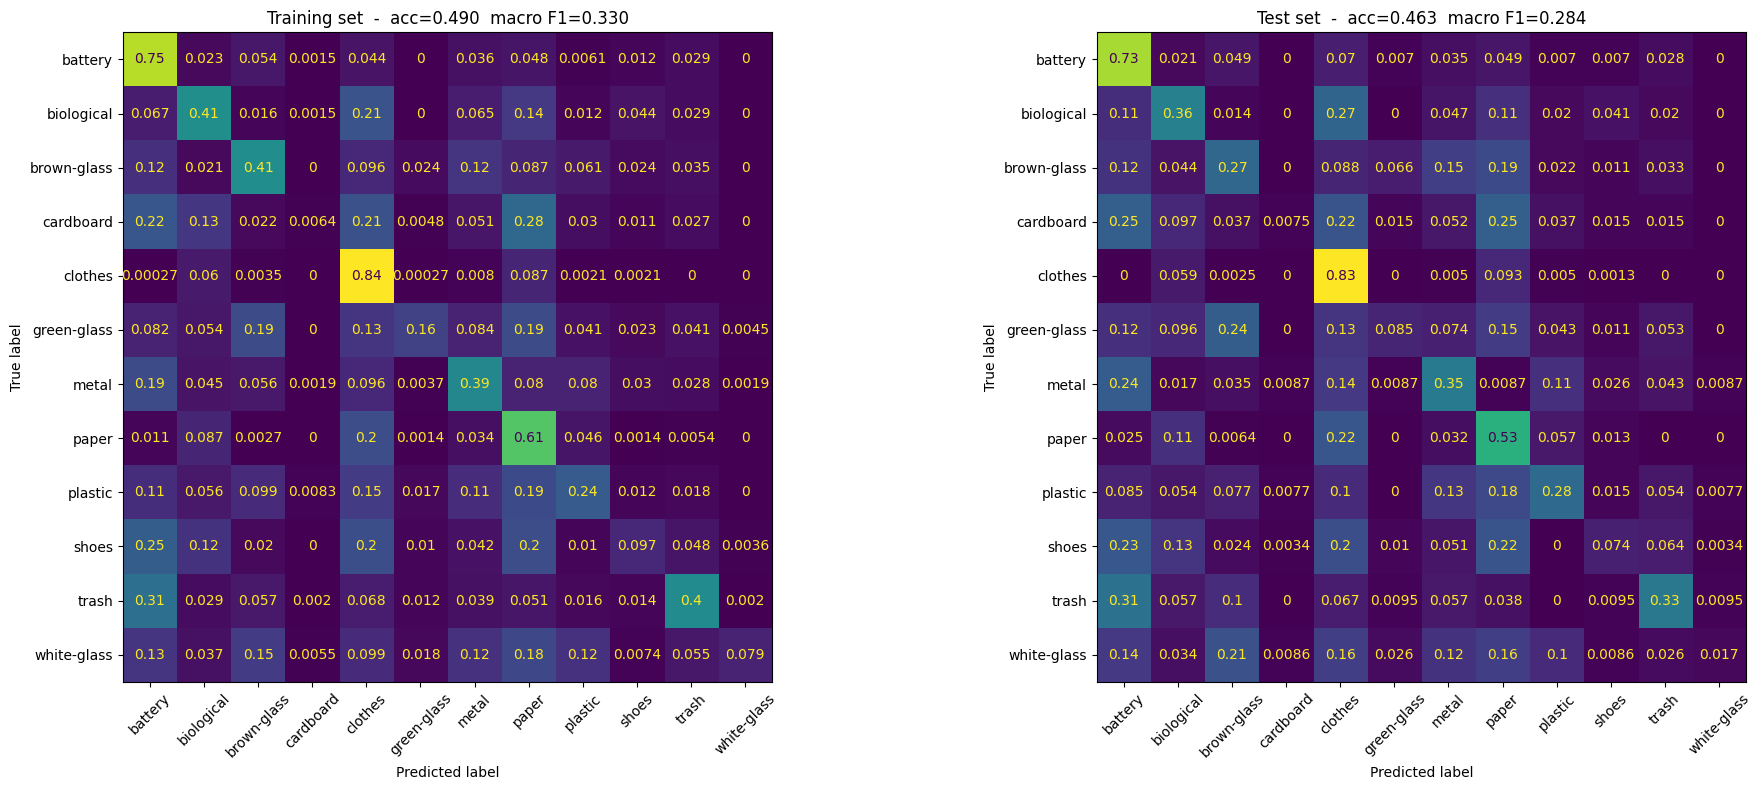

              precision    recall  f1-score   support

     battery     0.3084    0.7254    0.4328       142
  biological     0.2634    0.3649    0.3059       148
 brown-glass     0.2066    0.2747    0.2358        91
   cardboard     0.2000    0.0075    0.0144       134
     clothes     0.7290    0.8348    0.7783       799
 green-glass     0.3200    0.0851    0.1345        94
       metal     0.2837    0.3478    0.3125       115
       paper     0.2325    0.5287    0.3230       157
     plastic     0.4111    0.2846    0.3364       130
       shoes     0.5116    0.0741    0.1294       297
       trash     0.4070    0.3333    0.3665       105
 white-glass     0.3333    0.0172    0.0328       116

    accuracy                         0.4626      2328
   macro avg     0.3506    0.3232    0.2835      2328
weighted avg     0.4711    0.4626    0.4191      2328

------------------------------------------------------------
Computational cost:
  training time   : 3.76s
  inference time  : 0.073s

In [28]:
from sklearn.ensemble import RandomForestClassifier

t0 = time.perf_counter()
rf1 = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=RANDOM_STATE,
    class_weight='balanced_subsample',
    n_jobs=-1,
).fit(X_train, Y_train)
train_time_1 = time.perf_counter() - t0

result_1 = eval_model(rf1, X_train, Y_train, X_test, Y_test, class_list,
                      train_time=train_time_1)

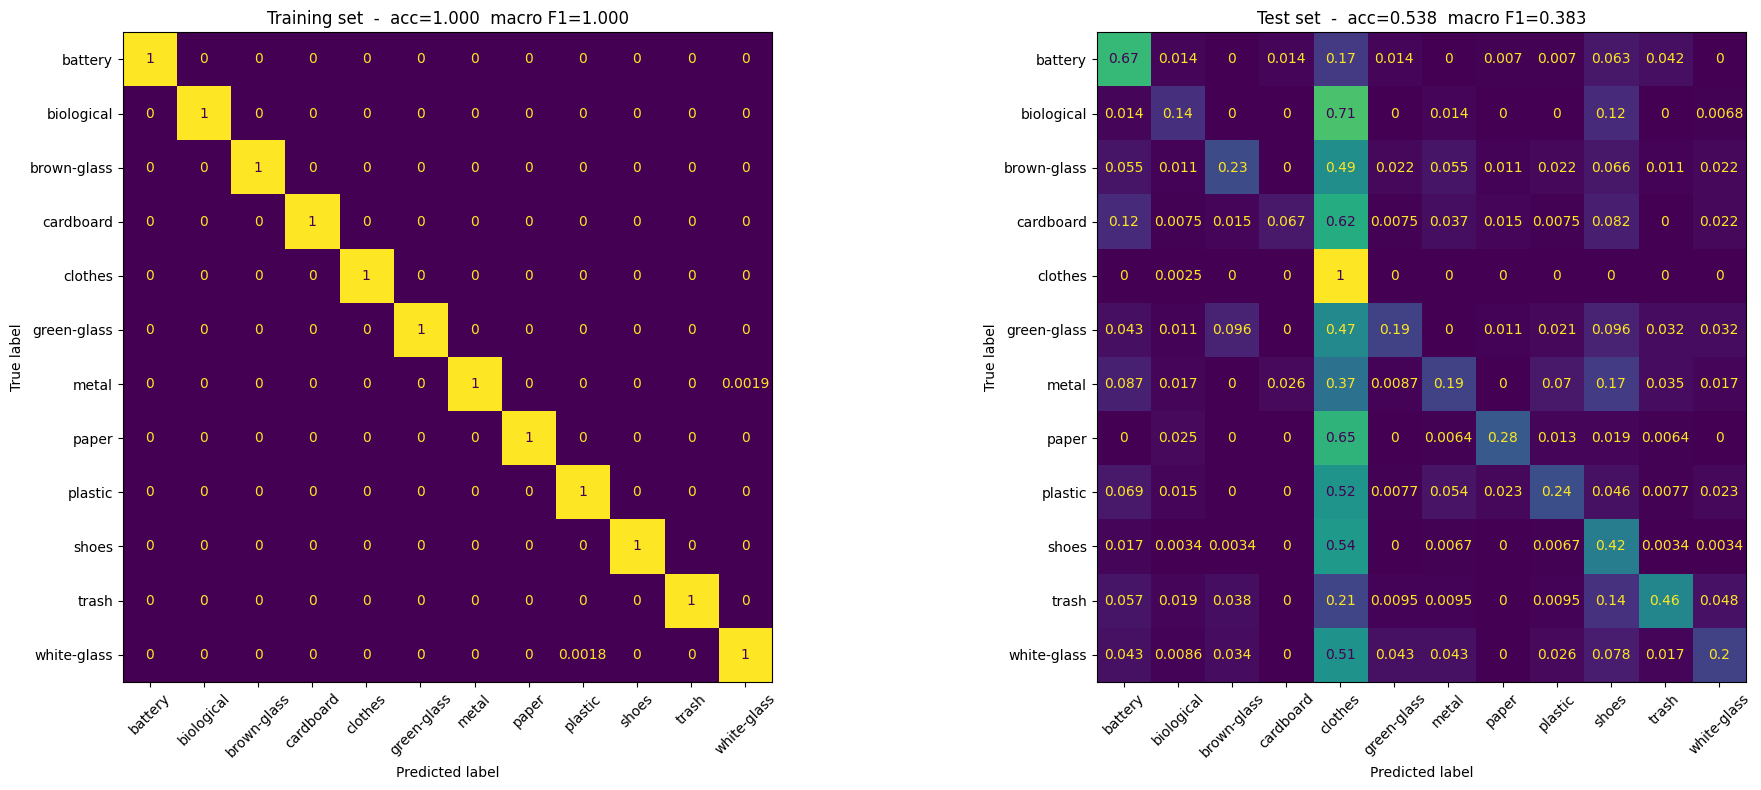

              precision    recall  f1-score   support

     battery     0.6051    0.6690    0.6355       142
  biological     0.5128    0.1351    0.2139       148
 brown-glass     0.5122    0.2308    0.3182        91
   cardboard     0.6429    0.0672    0.1216       134
     clothes     0.5139    0.9975    0.6783       799
 green-glass     0.5806    0.1915    0.2880        94
       metal     0.4400    0.1913    0.2667       115
       paper     0.8462    0.2803    0.4211       157
     plastic     0.5849    0.2385    0.3388       130
       shoes     0.5391    0.4175    0.4706       297
       trash     0.7164    0.4571    0.5581       105
 white-glass     0.5349    0.1983    0.2893       116

    accuracy                         0.5378      2328
   macro avg     0.5857    0.3395    0.3833      2328
weighted avg     0.5656    0.5378    0.4763      2328

------------------------------------------------------------
Computational cost:
  training time   : 10.65s
  inference time  : 0.100

In [29]:
t0 = time.perf_counter()
rf2 = RandomForestClassifier(
    n_estimators=100,
    max_depth=32,
    random_state=RANDOM_STATE,
    class_weight='balanced_subsample',
    n_jobs=-1,
).fit(X_train, Y_train)
train_time_2 = time.perf_counter() - t0

result_2 = eval_model(rf2, X_train, Y_train, X_test, Y_test, class_list,
                      train_time=train_time_2)

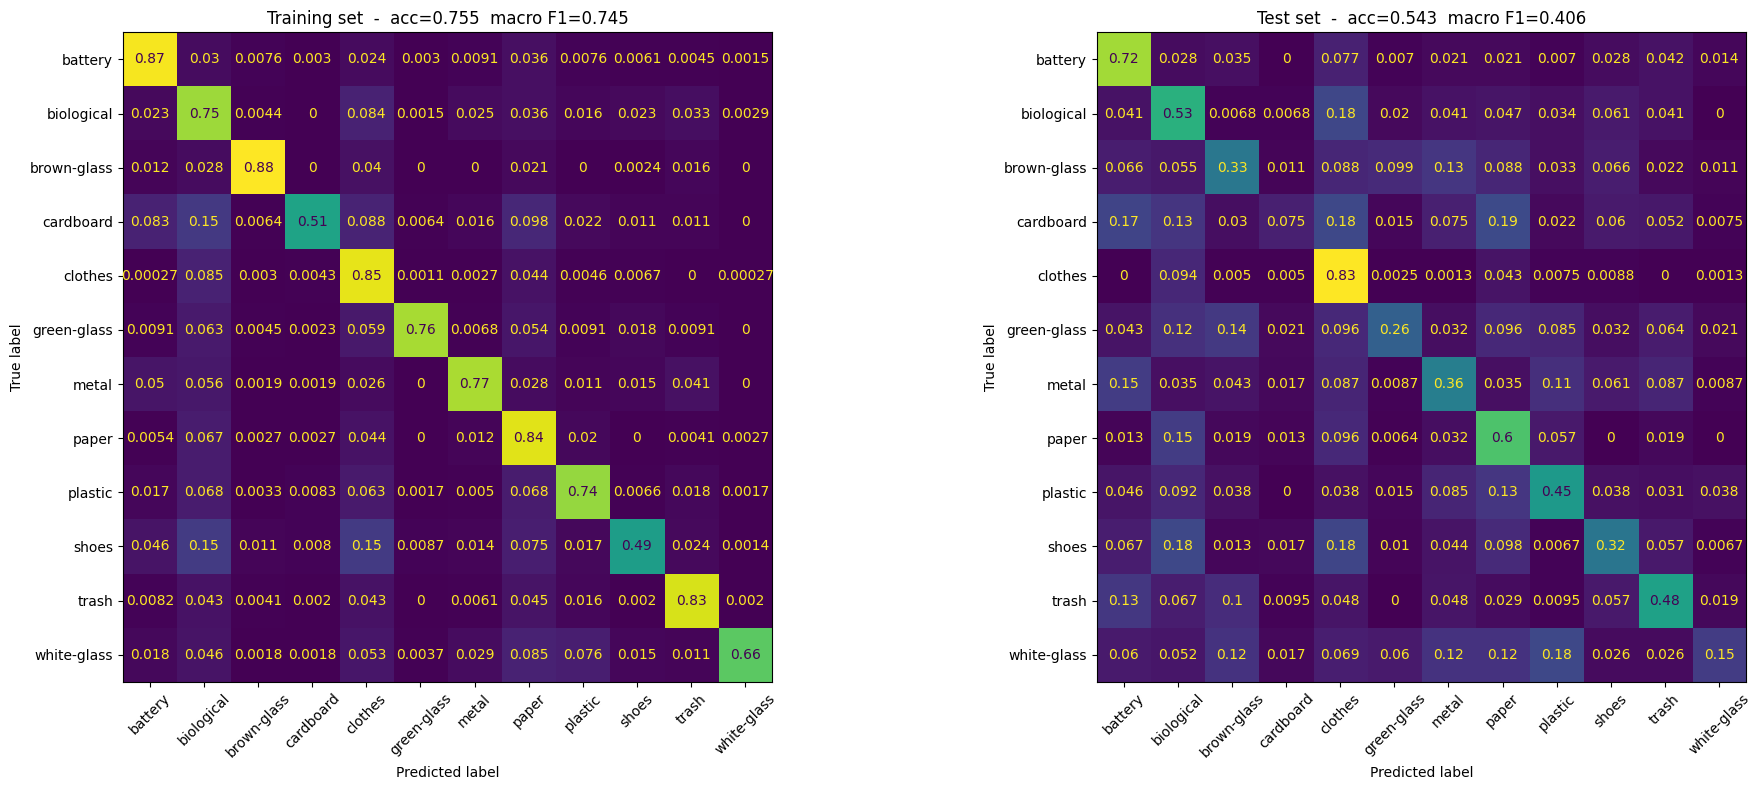

              precision    recall  f1-score   support

     battery     0.4928    0.7183    0.5845       142
  biological     0.2635    0.5270    0.3514       148
 brown-glass     0.3030    0.3297    0.3158        91
   cardboard     0.3333    0.0746    0.1220       134
     clothes     0.7936    0.8323    0.8125       799
 green-glass     0.4364    0.2553    0.3221        94
       metal     0.3306    0.3565    0.3431       115
       paper     0.3806    0.5987    0.4653       157
     plastic     0.4462    0.4462    0.4462       130
       shoes     0.6234    0.3232    0.4257       297
       trash     0.4386    0.4762    0.4566       105
 white-glass     0.5000    0.1466    0.2267       116

    accuracy                         0.5434      2328
   macro avg     0.4452    0.4237    0.4060      2328
weighted avg     0.5590    0.5434    0.5287      2328

------------------------------------------------------------
Computational cost:
  training time   : 6.98s
  inference time  : 0.072s

In [30]:
t0 = time.perf_counter()
rf3 = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=RANDOM_STATE,
    class_weight='balanced_subsample',
    n_jobs=-1,
).fit(X_train, Y_train)
train_time_3 = time.perf_counter() - t0

result_3 = eval_model(rf3, X_train, Y_train, X_test, Y_test, class_list,
                      train_time=train_time_3)

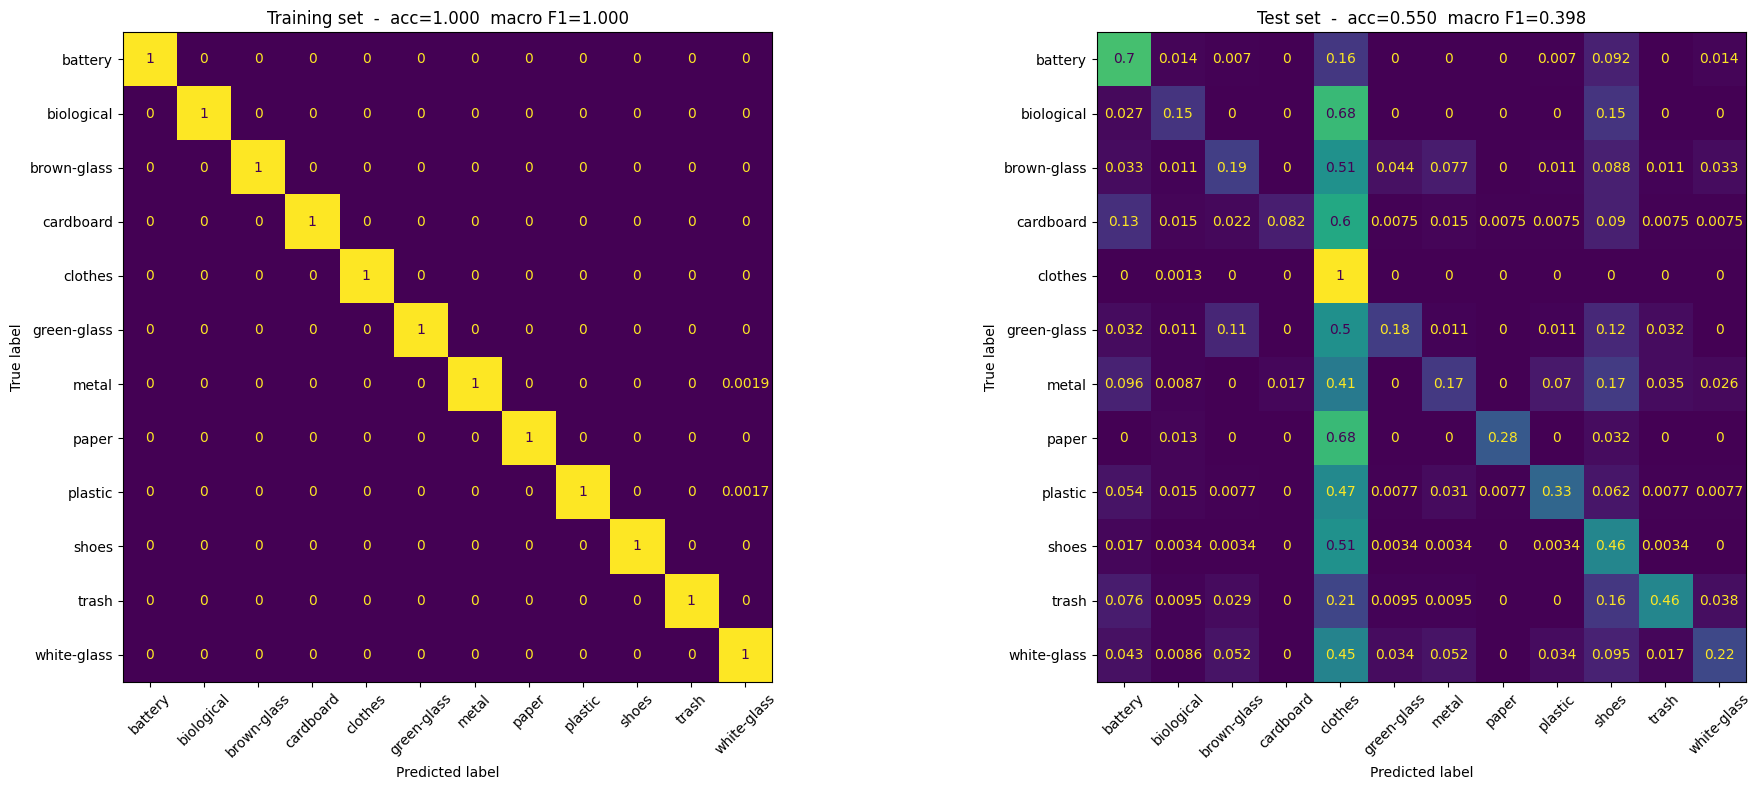

              precision    recall  f1-score   support

     battery     0.6098    0.7042    0.6536       142
  biological     0.5946    0.1486    0.2378       148
 brown-glass     0.4048    0.1868    0.2556        91
   cardboard     0.8462    0.0821    0.1497       134
     clothes     0.5205    0.9987    0.6844       799
 green-glass     0.5862    0.1809    0.2764        94
       metal     0.4634    0.1652    0.2436       115
       paper     0.9565    0.2803    0.4335       157
     plastic     0.7167    0.3308    0.4526       130
       shoes     0.5171    0.4579    0.4857       297
       trash     0.7869    0.4571    0.5783       105
 white-glass     0.6410    0.2155    0.3226       116

    accuracy                         0.5498      2328
   macro avg     0.6370    0.3507    0.3978      2328
weighted avg     0.6027    0.5498    0.4903      2328

------------------------------------------------------------
Computational cost:
  training time   : 34.47s
  inference time  : 0.195

In [31]:
t0 = time.perf_counter()
rf4 = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    random_state=RANDOM_STATE,
    class_weight='balanced_subsample',
    n_jobs=-1,
).fit(X_train, Y_train)
train_time_4 = time.perf_counter() - t0

result_4 = eval_model(rf4, X_train, Y_train, X_test, Y_test, class_list,
                      train_time=train_time_4)

In [32]:
# Side-by-side comparison of the four RF configurations
print(f'{"model":<45s}  {"acc":>6s}  {"macro F1":>9s}  {"train (s)":>10s}  {"infer (s)":>10s}')
print('-' * 90)

configs = [
    ('1. Shallow  (depth=4,  n=100, balanced)',   result_1),
    ('2. Deep     (depth=32, n=100, balanced)',   result_2),
    ('3. Moderate (depth=8,  n=100, balanced)',   result_3),
    ('4. Tuned    (depth=20, n=300, balanced)',   result_4),
]
for name, r in configs:
    print(f'{name:<45s}  {r["test_accuracy"]:>6.3f}  {r["test_macro_f1"]:>9.3f}  '
          f'{r["train_time_s"]:>10.2f}  {r["infer_time_s"]:>10.3f}')

model                                             acc   macro F1   train (s)   infer (s)
------------------------------------------------------------------------------------------
1. Shallow  (depth=4,  n=100, balanced)         0.463      0.284        3.76       0.073
2. Deep     (depth=32, n=100, balanced)         0.538      0.383       10.65       0.100
3. Moderate (depth=8,  n=100, balanced)         0.543      0.406        6.98       0.072
4. Tuned    (depth=20, n=300, balanced)         0.550      0.398       34.47       0.195


In [33]:
# Use Model 3 (best macro F1) for failure analysis
best_rf = rf3

Y_pred = best_rf.predict(X_test)
Y_prob = best_rf.predict_proba(X_test)

failures = get_failure_cases(
    test_paths, Y_test, Y_pred, Y_prob, class_list,
    top_k=12, mode='high_confidence',
)

print(f'Top 12 high-confidence misclassifications:')
print()
for f in failures:
    print(f"  true: {f['true_class']:>12s}  ->  pred: {f['pred_class']:>12s}  "
          f"(conf={f['confidence']:.3f})")

Top 12 high-confidence misclassifications:

  true:  green-glass  ->  pred:        trash  (conf=0.860)
  true:        trash  ->  pred:      battery  (conf=0.717)
  true:        shoes  ->  pred:      battery  (conf=0.676)
  true:        trash  ->  pred:      battery  (conf=0.524)
  true:    cardboard  ->  pred:      battery  (conf=0.516)
  true:        trash  ->  pred:      battery  (conf=0.514)
  true:    cardboard  ->  pred:      battery  (conf=0.498)
  true:        shoes  ->  pred:      battery  (conf=0.478)
  true:  green-glass  ->  pred:        trash  (conf=0.454)
  true:        shoes  ->  pred:      battery  (conf=0.445)
  true:        trash  ->  pred:      battery  (conf=0.426)
  true:  green-glass  ->  pred:  brown-glass  (conf=0.407)


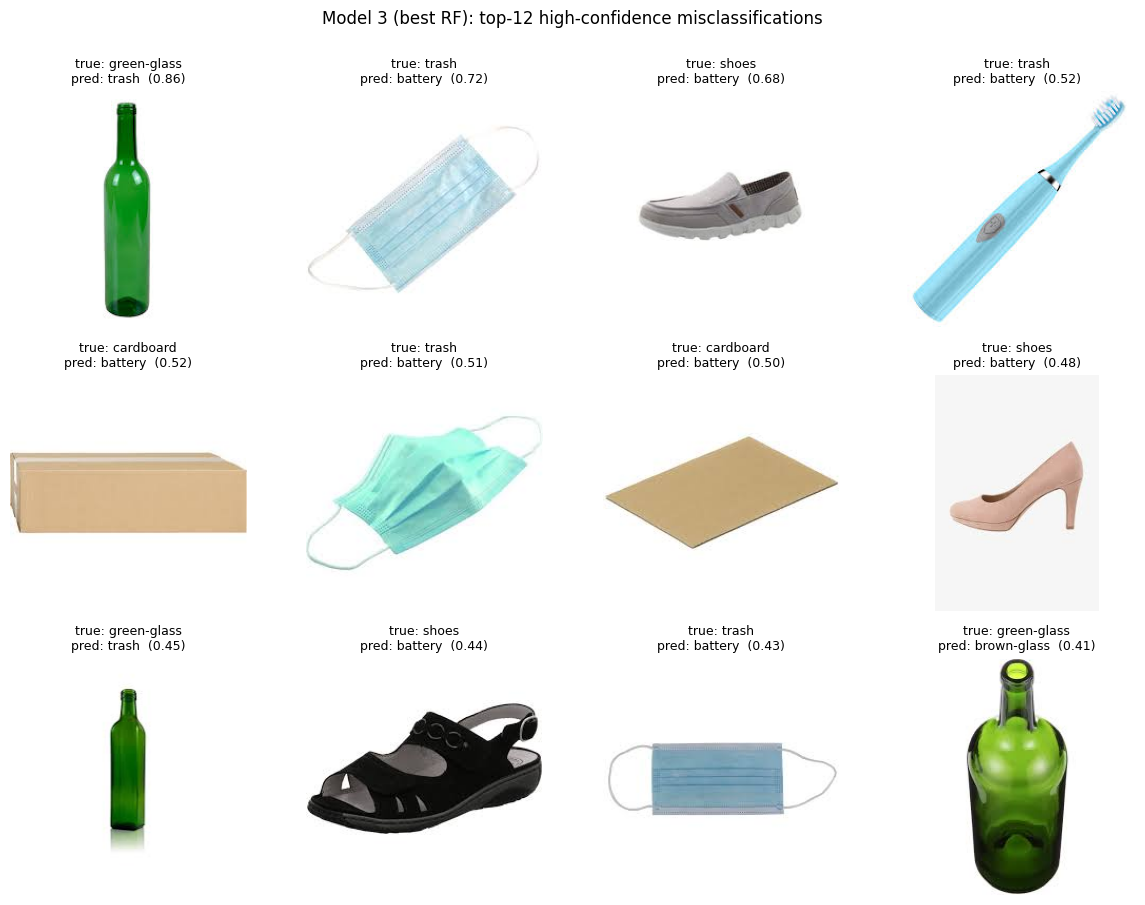

In [34]:
plot_failure_grid(
    failures,
    n_cols=4,
    title='Model 3 (best RF): top-12 high-confidence misclassifications',
)